## 4. Analysis / Modeling Module: Sentiment Analysis (Supervised ML)

Based on the provided `vectors_x_train_tfidf.pkl` and `labels_y_train.pkl` files, we will implement a supervised sentiment analysis model. We'll use `LogisticRegression` as a simple yet effective classifier for this task.

In [28]:
import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define paths for test features and labels
x_test_tfidf_path = os.path.join(features_path, 'vectors_x_test_tfidf.pkl')
y_train_path = os.path.join(features_path, 'labels_y_train.pkl')
y_test_path = os.path.join(features_path, 'labels_y_test.pkl')

print(f"Loading training features from: {X_train_tfidf_path}")
print(f"Loading training labels from: {y_train_path}")
print(f"Loading test features from: {x_test_tfidf_path}")
print(f"Loading test labels from: {y_test_path}")

# Load the pre-processed data
X_train_tfidf = joblib.load(X_train_tfidf_path)
X_test_tfidf = joblib.load(x_test_tfidf_path)
y_train = joblib.load(y_train_path)
y_test = joblib.load(y_test_path)

print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")
print(f"y_test shape: {y_test.shape}")

Loading training features from: /content/drive/MyDrive/22CDS0446_NLP/features/vectors_x_train_tfidf.pkl
Loading training labels from: /content/drive/MyDrive/22CDS0446_NLP/features/labels_y_train.pkl
Loading test features from: /content/drive/MyDrive/22CDS0446_NLP/features/vectors_x_test_tfidf.pkl
Loading test labels from: /content/drive/MyDrive/22CDS0446_NLP/features/labels_y_test.pkl
X_train_tfidf shape: (90962, 5000)
y_train shape: (90962,)
X_test_tfidf shape: (22741, 5000)
y_test shape: (22741,)


### Model Initialization and Training

We will use `LogisticRegression` to train our sentiment classification model. This model is well-suited for binary or multiclass classification tasks with sparse features like TF-IDF vectors.

In [29]:
# Initialize the Logistic Regression model
sentiment_model = LogisticRegression(max_iter=1000, random_state=42)

print("Training the Logistic Regression model...")
# Train the model
sentiment_model.fit(X_train_tfidf, y_train)

print("Model training complete.")

Training the Logistic Regression model...
Model training complete.


### Model Evaluation

After training, we evaluate the model's performance on the unseen test data using common metrics like accuracy and a classification report.

In [30]:
# Make predictions on the test set
y_pred = sentiment_model.predict(X_test_tfidf)

# Evaluate the model
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.5673

Classification Report:
                                                                                precision    recall  f1-score   support

                               $10,000 Every Day You Survive In The Wilderness       0.46      0.41      0.43      2005
                          100 Strongest Vs 100 Smartest Compete for $5,000,000       0.63      0.27      0.38       867
                                             50 YouTubers Fight For $1,000,000       0.72      0.53      0.61      2006
                                      AMP EXTREME OBSTACLE COURSE WITH MRBEAST       0.67      0.58      0.62      1817
David Guetta - Hey Mama (Official Video) ft Nicki Minaj, Bebe Rexha & Afrojack       0.56      0.90      0.69      4013
                                           I Built 10 Schools Around The World       0.49      0.50      0.49      2002
                                        I Granted 100 Kids Their Biggest Wish!       0.49      0.48 

### How to Use the Trained Model

To use this trained sentiment analysis model for new text data, you need to perform the following steps:

1.  **Load the trained model**: Use `joblib.load()` to load the `.pkl` file.
2.  **Pre-process new text**: Apply the same TF-IDF vectorizer that was used to create `X_train_tfidf` to your new text. This typically involves loading the saved `TfidfVectorizer` object and transforming the new text data.
3.  **Predict sentiment**: Use the loaded model's `predict()` method on the TF-IDF vectorized new text.

**Note**: The TF-IDF vectorizer itself would also need to be saved and loaded to ensure consistent preprocessing for new data. For demonstration purposes, we will assume you have a way to generate TF-IDF vectors for new input that matches the training data's feature space.

In [31]:
# Save the trained model
model_output_filename = 'sentiment_logistic_regression_model.pkl'
model_output_path = os.path.join(features_path, model_output_filename)
joblib.dump(sentiment_model, model_output_path)

print(f"Trained Logistic Regression model saved to: {model_output_path}")

# Example of how to load and use the model for prediction (conceptual, as TfidfVectorizer is not loaded here)
# In a real scenario, you would also load your trained TfidfVectorizer
# For example:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf_vectorizer = joblib.load(os.path.join(features_path, 'tfidf_vectorizer.pkl')) # Assuming it was saved

# loaded_model = joblib.load(model_output_path)
# new_text_data = ["This is a great product!", "I am very disappointed with the service."]
# new_text_tfidf = tfidf_vectorizer.transform(new_text_data) # This step requires the loaded tfidf_vectorizer
# predictions = loaded_model.predict(new_text_tfidf)
# print(f"Predictions for new text: {predictions}")

Trained Logistic Regression model saved to: /content/drive/MyDrive/22CDS0446_NLP/features/sentiment_logistic_regression_model.pkl


## 5. Visualization / Output Module

Now, let's visualize the results of our sentiment analysis model. We'll start with the classification report and then look at the distribution of predicted sentiments.

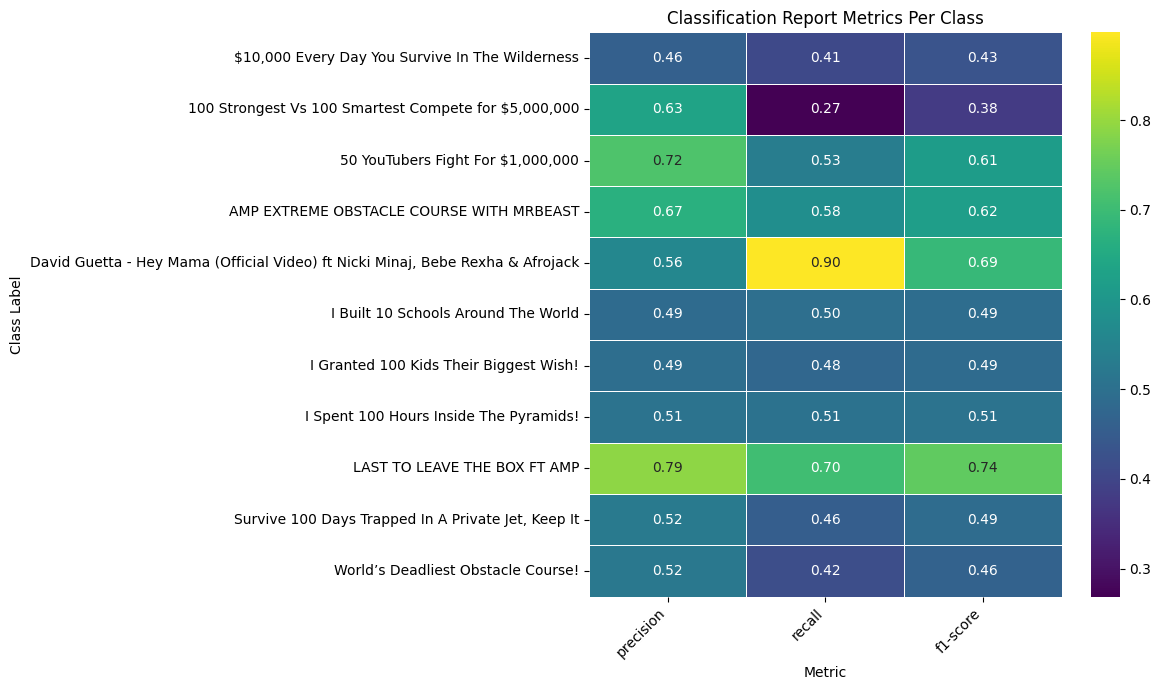

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

# Re-generate the classification report as a dictionary for easier parsing
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert the report dictionary to a DataFrame, excluding 'accuracy', 'macro avg', 'weighted avg'
# and converting to a long format for plotting
metrics_df = pd.DataFrame(report_dict).transpose()
metrics_df = metrics_df.drop(columns=['support'])

# Drop aggregate rows to only show per-class metrics
class_metrics_df = metrics_df.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Plotting Precision, Recall, F1-score for each class
plt.figure(figsize=(12, 7))
sns.heatmap(class_metrics_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Classification Report Metrics Per Class')
plt.xlabel('Metric')
plt.ylabel('Class Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Distribution of Predicted Classes

This chart shows how many instances were predicted for each sentiment class by our model.

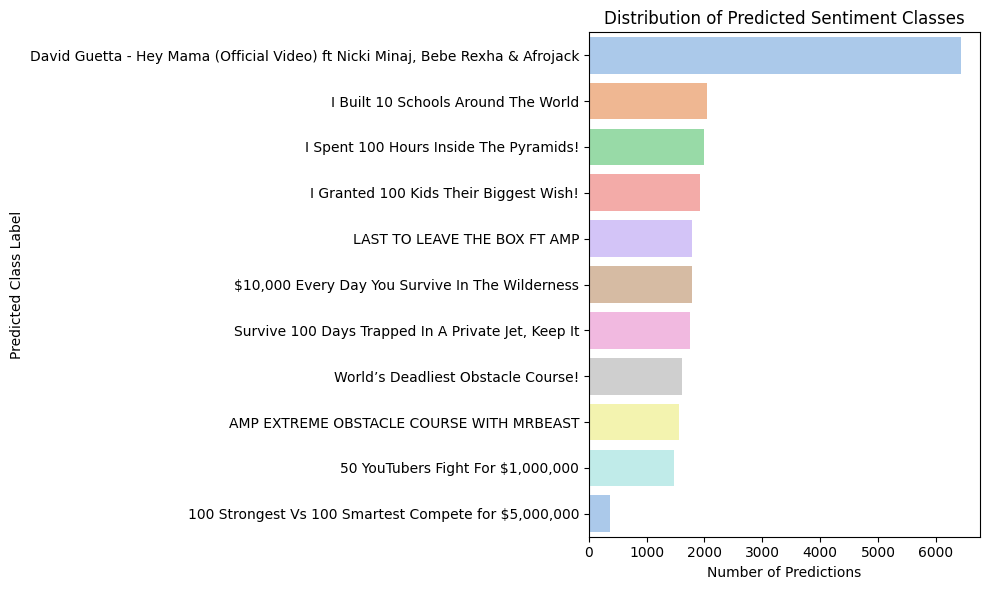

In [33]:
# Visualize the distribution of predicted classes
plt.figure(figsize=(10, 6))
sns.countplot(y=y_pred, order=pd.Series(y_pred).value_counts().index, palette='pastel')
plt.title('Distribution of Predicted Sentiment Classes')
plt.xlabel('Number of Predictions')
plt.ylabel('Predicted Class Label')
plt.tight_layout()
plt.show()


### Additional Visualization Notes

*   **Topic Wordclouds**: To generate topic wordclouds, we first need to perform Topic Modeling (e.g., using LDA or BERTopic), which was outlined as 'PATH 2' in your pipeline. This step has not been implemented yet.

*   **Sentiment Over Time Trend**: This visualization requires a `date` column in your metadata to analyze sentiment trends over time. Currently, the `metadata` DataFrame is empty and no date information has been provided or extracted. If you can provide or process date information, we can then generate this plot.